<a href="https://colab.research.google.com/github/busetas/Roketsan_Sensor/blob/main/06_PID_Kontrol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PID (Oransal-İntegral-Türev) Kontrolcü, otonom sistemlerde istenen hedefe (Setpoint) yumuşak ve kararlı bir şekilde ulaşmak için kullanılan en yaygın kapalı döngü (Feedback) kontrol mekanizmasıdır.

P (Proportional - Oransal): Mevcut hatayla orantılı tepki verir. Hatayı hızlı kapatır ama hedefe tam ulaşamayıp kalıcı durum hatası (Steady-state error) bırakır.

I (Integral - İntegral): Zamanla biriken geçmiş hataları toplar. Kalıcı durum hatasını sıfırlar ancak aşım (overshoot) yaptırabilir.

D (Derivative - Türev): Hatadaki değişim hızına (geleceğe) bakar. Fren etkisi yaparak salınımları (oscillation) söndürür.


**💻 Canlı P, PI, PD, PID Karşılaştırma Simülasyonu**

Aşağıdaki kod, $0$ konumunda duran bir aracın $100\text{ metrelik}$ hedefe ulaşma sürecini P, PI, PD ve PID kontrolcüler için aynı anda simüle edip canlı olarak karşılaştırmaktadır.

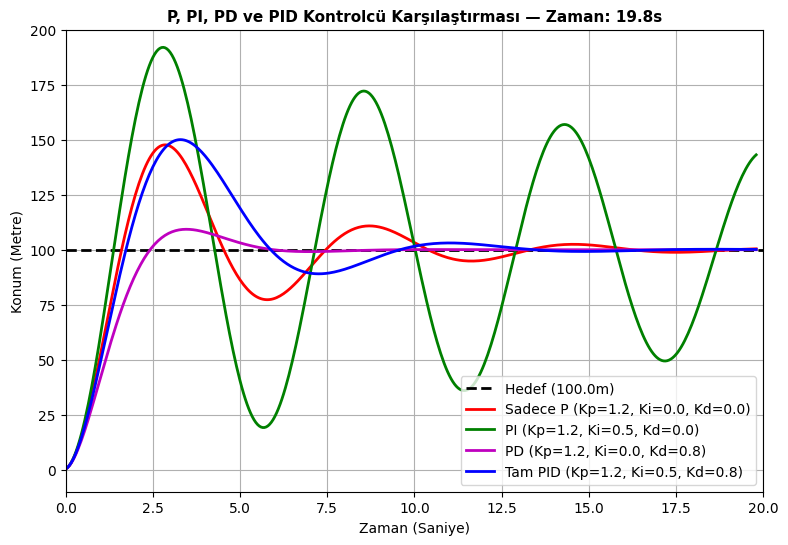

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# ==========================================
# 1. ARAÇ SİSTEM MODELİ VEYA SİMÜLASYON PARAMETRELERİ
# ==========================================
target = 100.0       # Hedef Konum (m)
total_time = 20.0    # Simülasyon Süresi (s)
dt = 0.05            # Zaman Adımı (s)
steps = int(total_time / dt)

# Kontrolcü Parametreleri (Kp, Ki, Kd)
controllers = {
    'Sadece P':  {'Kp': 1.2, 'Ki': 0.0, 'Kd': 0.0, 'color': 'r'},
    'PI':        {'Kp': 1.2, 'Ki': 0.5, 'Kd': 0.0, 'color': 'g'},
    'PD':        {'Kp': 1.2, 'Ki': 0.0, 'Kd': 0.8, 'color': 'm'},
    'Tam PID':   {'Kp': 1.2, 'Ki': 0.5, 'Kd': 0.8, 'color': 'b'}
}

# Durum Değişkenleri
state = {name: {'pos': 0.0, 'vel': 0.0, 'integral': 0.0, 'prev_error': 0.0, 'history': []}
         for name in controllers}

# Araç Fizik Parametreleri (Kütle ve Sürtünme)
mass = 1.0
damping = 0.5

# ==========================================
# 2. CANLI SİMÜLASYON DÖNGÜSÜ
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))
time_hist = []

for i in range(steps):
    t = i * dt
    time_hist.append(t)

    for name, params in controllers.items():
        st = state[name]

        # 1. Hata Hesaplama
        error = target - st['pos']

        # 2. İntegral ve Türev
        st['integral'] += error * dt
        derivative = (error - st['prev_error']) / dt if i > 0 else 0.0
        st['prev_error'] = error

        # 3. Kontrol Sinyali (Kuvvet): U = Kp*e + Ki*∫e + Kd*de/dt
        u = (params['Kp'] * error) + (params['Ki'] * st['integral']) + (params['Kd'] * derivative)

        # 4. Fiziksel Simülasyon (F = ma => a = (F - damping*v) / m)
        acc = (u - damping * st['vel']) / mass
        st['vel'] += acc * dt
        st['pos'] += st['vel'] * dt

        st['history'].append(st['pos'])

    # --- CANLI GÖRSELLEŞTİRME (Her 4 Adımda Bir) ---
    if i % 4 == 0:
        ax.clear()

        # Hedef Çizgisi
        ax.axhline(target, color='k', linestyle='--', linewidth=2, label=f'Hedef ({target}m)')

        # Her Kontrolcünün Eğrisini Çiz
        for name, params in controllers.items():
            ax.plot(time_hist, state[name]['history'], color=params['color'],
                    linewidth=2, label=f"{name} (Kp={params['Kp']}, Ki={params['Ki']}, Kd={params['Kd']})")

        ax.set_title(f"P, PI, PD ve PID Kontrolcü Karşılaştırması — Zaman: {t:.1f}s", fontsize=11, fontweight='bold')
        ax.set_xlabel("Zaman (Saniye)")
        ax.set_ylabel("Konum (Metre)")
        ax.set_ylim(-10, 200)
        ax.set_xlim(0, total_time)
        ax.grid(True)
        ax.legend(loc='lower right')

        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

plt.close(fig)

🧐 Grafikte Neler Gördük?

Sadece P (Kırmızı Çizgi): Hedefe yaklaştı, ancak sürtünme nedeniyle $100\text{ m}$ çizgisine ulaşamadı, bir miktar Kalıcı Durum Hatası ile devam etti/edecek.

PI (Yeşil Çizgi): İntegral etkisi sayesinde hedefe tam ulaştı ama hedefi belirgin şekilde aştı (Overshoot/Aşım) ve salınım yaptı.

PD (Mor Çizgi): Türev fren etkisi yaptı; hareket çok pürüzsüz ama yine $100\text{ m}$ çizgisine tam oturamadı.

Tam PID (Mavi Çizgi): Hem hızlıca hedefe kilitlendi, hem de aşım yapmadan tam $100\text{ m}$ çizgisine mükemmel şekilde oturdu.

----------------------------------------
Ziegler-Nichols (Z-N) Kapalı Döngü Metodu, PID parametrelerini elle deneme-yanılma yapmak yerine sistematik ve otomatik olarak hesaplamak için kullanılır.

**📐 Ziegler-Nichols Metodu Nasıl Çalışır?**

Kritik Kazanç ($K_u$) Tespiti:

$K_i = 0$ ve $K_d = 0$ yapılır.

Sadece $K_p$ değeri artırılır.

Sistemin ne aşırı sönümlendiği ne de kontrolden çıktığı, sürekli ve kararlı bir salınıma (sustained oscillation) girdiği sınır noktadaki kazanç $K_u$ (Ultimate Gain) olarak kaydedilir.

Kritik Periyot ($T_u$) Tespiti:

Bu kararlı salınımın bir tam dalga boyunun süresi ($T_u$ / Ultimate Period) ölçülür.

Parametre Hesaplama: İstenen kontrolcü tipine göre standart Z-N tablosu kullanılarak parametreler otomatik türetilir:

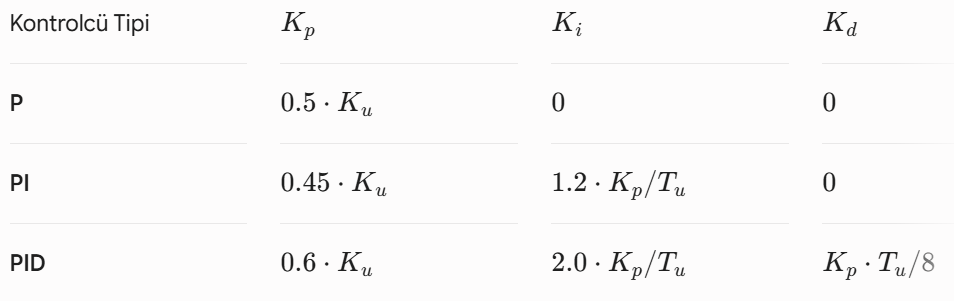

--------------------------------------------
**💻 Canlı Ziegler-Nichols Otomatik Arama ve PID Simülasyonu**

Aşağıdaki kod iki aşamadan oluşmaktadır:

1. Aşama: Otomatik arama döngüsü $K_p$ değerini kademeli artırarak sürekli salınımın yakalandığı $K_u$ ve $T_u$ değerlerini otomatik bulur.

2. Aşama: Bulunan $K_u$ ve $T_u$ üzerinden Z-N formülleri ile hesaplanan PID parametreleri sisteme uygulanır ve canlı simüle edilir.

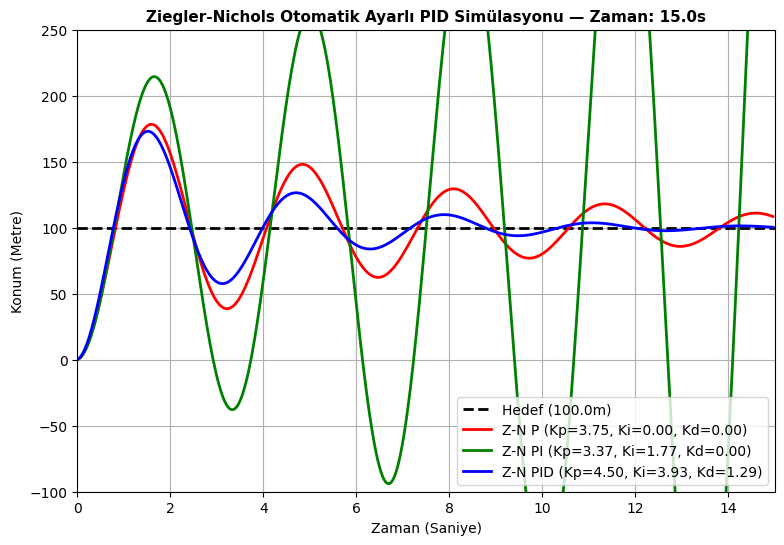

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# ==========================================
# 1. SİSTEM FİZİK MODELİ VE PARAMETRELERİ
# ==========================================
target = 100.0
dt = 0.02
mass = 1.0
damping = 0.3

def simulate_step(pos, vel, u, dt, mass=1.0, damping=0.3):
    acc = (u - damping * vel) / mass
    vel_new = vel + acc * dt
    pos_new = pos + vel_new * dt
    return pos_new, vel_new

# ==========================================
# 2. OTOMATİK ZIEGLER-NICHOLS ARAMA AŞAMASI
# ==========================================
print("Ziegler-Nichols parametreleri otomatik aranıyor...")

kp_test = 0.1
ku = None
tu = None

# Ku ve Tu tespiti için tarama döngüsü
while kp_test < 20.0:
    pos, vel = 0.0, 0.0
    history = []

    # 15 saniye boyunca sadece P kontrolcü ile testi çalıştır
    test_steps = int(15.0 / dt)
    for step in range(test_steps):
        error = target - pos
        u = kp_test * error
        pos, vel = simulate_step(pos, vel, u, dt, mass, damping)
        history.append(pos)

    history = np.array(history)
    # Son 5 saniyedeki tepe noktalarını (peaks) bul
    last_samples = int(5.0 / dt)
    recent_history = history[-last_samples:]

    peaks = []
    for idx in range(1, len(recent_history) - 1):
        if recent_history[idx] > recent_history[idx-1] and recent_history[idx] > recent_history[idx+1]:
            peaks.append(idx * dt)

    # Eğer en az 3 tepe noktası varsa ve genlikler kararlı salınımdaysa Ku ve Tu bulundu demektir
    if len(peaks) >= 3:
        peak_diffs = np.diff(peaks)
        # Tepe noktaları arası süreler eşit mi (kararlı salınım kontrolü)
        if np.std(peak_diffs) < 0.05:
            ku = kp_test
            tu = np.mean(peak_diffs)
            break

    kp_test += 0.1

print(f"✅ Kritik Kazanç (Ku): {ku:.2f}")
print(f"✅ Kritik Periyot (Tu): {tu:.2f} saniye\n")

# Z-N Tablosuna Göre Otomatik Parametre Hesaplama
zn_params = {
    'Z-N P':   {'Kp': 0.5 * ku,       'Ki': 0.0,                 'Kd': 0.0,            'color': 'r'},
    'Z-N PI':  {'Kp': 0.45 * ku,      'Ki': (0.45*ku*1.2)/tu,    'Kd': 0.0,            'color': 'g'},
    'Z-N PID': {'Kp': 0.6 * ku,       'Ki': (0.6*ku*2.0)/tu,     'Kd': (0.6*ku*tu)/8.0,'color': 'b'}
}

for key, p in zn_params.items():
    print(f"{key:8s} -> Kp: {p['Kp']:.2f} | Ki: {p['Ki']:.2f} | Kd: {p['Kd']:.2f}")

# ==========================================
# 3. OTOMATİK HESAPLANAN PID İLE CANLI SİMÜLASYON
# ==========================================
total_time = 15.0
steps = int(total_time / dt)

state = {name: {'pos': 0.0, 'vel': 0.0, 'integral': 0.0, 'prev_error': 0.0, 'history': []}
         for name in zn_params}

fig, ax = plt.subplots(figsize=(9, 6))
time_hist = []

for i in range(steps):
    t = i * dt
    time_hist.append(t)

    for name, params in zn_params.items():
        st = state[name]

        error = target - st['pos']
        st['integral'] += error * dt
        derivative = (error - st['prev_error']) / dt if i > 0 else 0.0
        st['prev_error'] = error

        u = (params['Kp'] * error) + (params['Ki'] * st['integral']) + (params['Kd'] * derivative)
        st['pos'], st['vel'] = simulate_step(st['pos'], st['vel'], u, dt, mass, damping)
        st['history'].append(st['pos'])

    # --- CANLI GÖRSELLEŞTİRME ---
    if i % 4 == 0:
        ax.clear()
        ax.axhline(target, color='k', linestyle='--', linewidth=2, label=f'Hedef ({target}m)')

        for name, params in zn_params.items():
            ax.plot(time_hist, state[name]['history'], color=params['color'],
                    linewidth=2, label=f"{name} (Kp={params['Kp']:.2f}, Ki={params['Ki']:.2f}, Kd={params['Kd']:.2f})")

        ax.set_title(f"Ziegler-Nichols Otomatik Ayarlı PID Simülasyonu — Zaman: {t:.1f}s", fontsize=11, fontweight='bold')
        ax.set_xlabel("Zaman (Saniye)")
        ax.set_ylabel("Konum (Metre)")
        ax.set_ylim(-100, 250)
        ax.set_xlim(0, total_time)
        ax.grid(True)
        ax.legend(loc='lower right')

        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

plt.close(fig)

In [ ]:
# Standart Z-N PI (Agresif / Sapıtan):
Kp = 0.45 * Ku
Ki = (0.45 * Ku * 1.2) / Tu

# Yumuşatılmış (No-Overshoot) PI (Kararlı ve Pürüzsüz):
Kp = 0.20 * Ku
Ki = (0.20 * Ku * 0.4) / Tu